# Predicting Diabetes Risk from Diagnostic Measurements
### A Data Mining Course Project

**Problem:** Predict whether a patient is at risk of diabetes using routine diagnostic measurements (glucose level, BMI, age, etc.), to support early screening.

**Dataset:** Pima Indians Diabetes Dataset (768 patients, 8 features, 1 binary target)

**Author:** *(add your name here)*
**Course:** Data Mining Algorithms


## 1. Problem Statement

Diabetes is one of the most common chronic diseases worldwide, and early detection significantly
improves patient outcomes and reduces long-term treatment costs. Many patients are not diagnosed
until symptoms are already severe.

**Goal of this project:** build a classification model that predicts whether a patient is likely
to have diabetes, using only routine, low-cost diagnostic measurements (number of pregnancies,
glucose level, blood pressure, skin thickness, insulin level, BMI, diabetes pedigree function,
and age). Such a model could support doctors and clinics as a low-cost, first-pass screening tool
to flag at-risk patients for further testing — it is **not** meant to replace a clinical diagnosis.

This is framed as a **binary classification** problem: `Outcome = 1` (has diabetes) vs.
`Outcome = 0` (no diabetes).


## 2. Dataset Description

**Source:** [Pima Indians Diabetes Dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv)
(originally from the National Institute of Diabetes and Digestive and Kidney Diseases, distributed
via the UCI Machine Learning Repository and mirrored on GitHub).

**Size:** 768 patient records (all female patients, at least 21 years old, of Pima Indian heritage).

**Features (8 numeric input features + 1 binary target):**

| Feature | Description |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skinfold thickness (mm) |
| `Insulin` | 2-Hour serum insulin (mu U/ml) |
| `BMI` | Body mass index (weight in kg / height in m²) |
| `DiabetesPedigreeFunction` | A score of diabetes likelihood based on family history |
| `Age` | Age in years |
| `Outcome` | **Target.** 1 = has diabetes, 0 = does not |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/diabetes.csv")
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 3. Data Preprocessing

### 3.1 Data Quality Issue: Hidden Missing Values

This dataset does not contain any `NaN` values as recognized by pandas — but several columns
contain the value **0** in places where 0 is **biologically impossible** for a living patient
(e.g. `Glucose = 0`, `BMI = 0`). These zeros are almost certainly missing measurements that were
recorded as 0 by whoever compiled the data, not real clinical values.


In [4]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print(f"{'Column':25s}{'# of Zeros':>12s}{'% of Data':>12s}")
for col in zero_as_missing_cols:
    n_zero = (df[col] == 0).sum()
    pct = n_zero / len(df) * 100
    print(f"{col:25s}{n_zero:12d}{pct:11.1f}%")

Column                     # of Zeros   % of Data
Glucose                             5        0.7%
BloodPressure                      35        4.6%
SkinThickness                     227       29.6%
Insulin                           374       48.7%
BMI                                11        1.4%


**Insulin (48.7%) and SkinThickness (29.6%) are missing for a very large share of patients** —
this is the most important data quality issue in this dataset, and shapes several decisions below.

### 3.2 Duplicate Records


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


No duplicate rows were found.

### 3.3 Class Balance


Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.1%
1    34.9%
Name: proportion, dtype: str


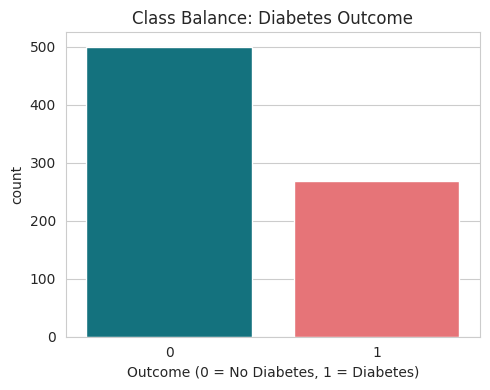

In [6]:
print(df["Outcome"].value_counts())
print()
print((df["Outcome"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

plt.figure(figsize=(5,4))
sns.countplot(x="Outcome", hue="Outcome", data=df, palette=["#028090","#F96167"], legend=False)
plt.title("Class Balance: Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.tight_layout()
plt.show()

The dataset is **moderately imbalanced**: 65.1% negative (no diabetes) vs. 34.9% positive
(diabetes). This is not severe enough to require resampling (e.g. SMOTE), but it does mean plain
accuracy alone can be misleading — we report Precision, Recall, F1, and ROC-AUC as well.

### 3.4 Feature Correlations


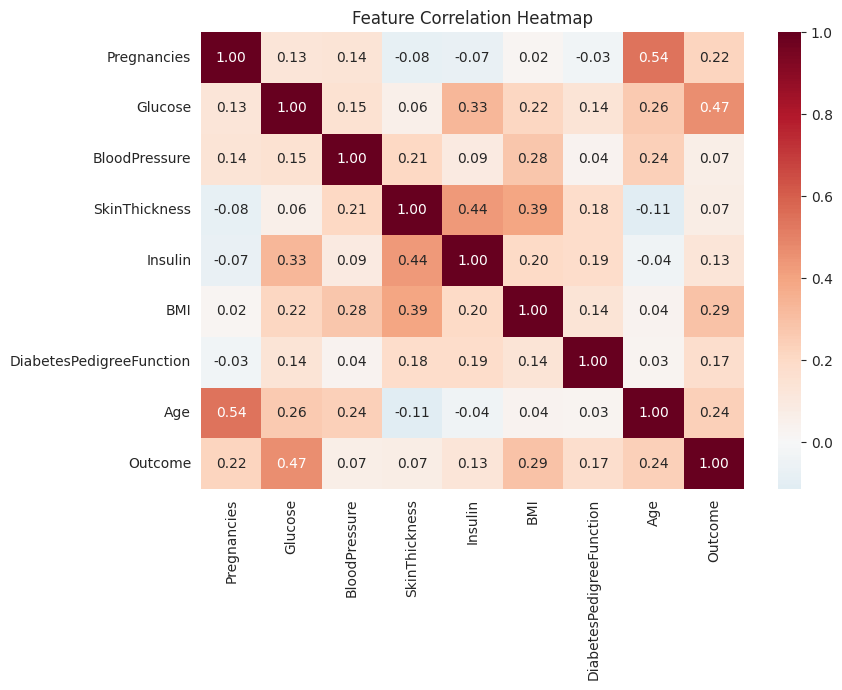

In [7]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

`Glucose` (0.47) and `BMI` (0.29) have the strongest correlation with `Outcome`, which matches
clinical expectations — blood glucose level is the primary diagnostic marker for diabetes.
`Age` and `Pregnancies` are also correlated with each other (0.54), which makes sense (older
patients have had more opportunities to have been pregnant) but is not a concern for tree-based
models and is only a mild concern for linear models.

### 3.5 Feature Distributions


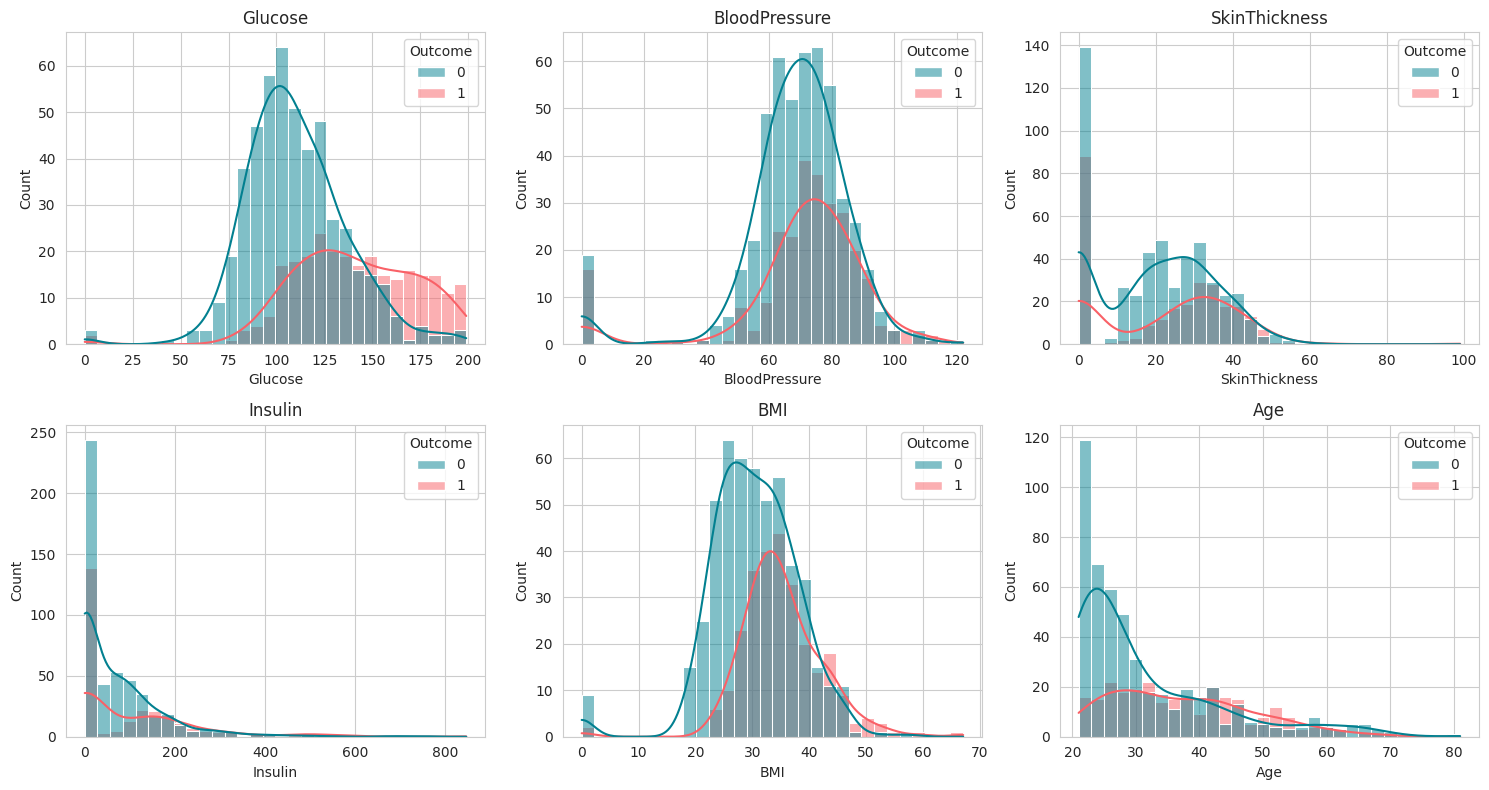

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(zero_as_missing_cols + ["Age"]):
    sns.histplot(data=df, x=col, hue="Outcome", bins=30, kde=True, ax=axes[i], palette=["#028090","#F96167"])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.6 Handling Missing Values — Important Methodological Note

A first, naive approach might be to fill each column's zeros with that column's median (or the
median computed **separately for diabetic vs. non-diabetic patients**). We deliberately **do not**
do this before splitting the data, for two reasons:

1. **Target leakage:** filling missing values using a statistic computed *per class* (grouped by
   `Outcome`) directly encodes the target label into the feature for every row that was originally
   missing. Since ~49% of `Insulin` values are missing, this would leak a large amount of target
   information into the model and produce an unrealistically high, unfair accuracy score.
2. **Train/test leakage:** computing *any* statistic (median, mean) from the full dataset —
   including rows that will later become the test set — leaks test-set information into training.

**Correct approach used here:** the train/test split happens first. Then a `SimpleImputer`
(median strategy) is **fit only on the training data**, and the *same* fitted values are applied
to fill missing values in both the training and test sets. This is done inside the modeling
pipeline in Section 5, using scikit-learn's `SimpleImputer`.

### 3.7 Feature Engineering (Exploratory)

For exploration, three categorical features were engineered from the continuous variables. These
are used only for visualization / interpretation in this notebook, not as model inputs, since the
raw numeric values already carry this information for the algorithms used in Section 5.


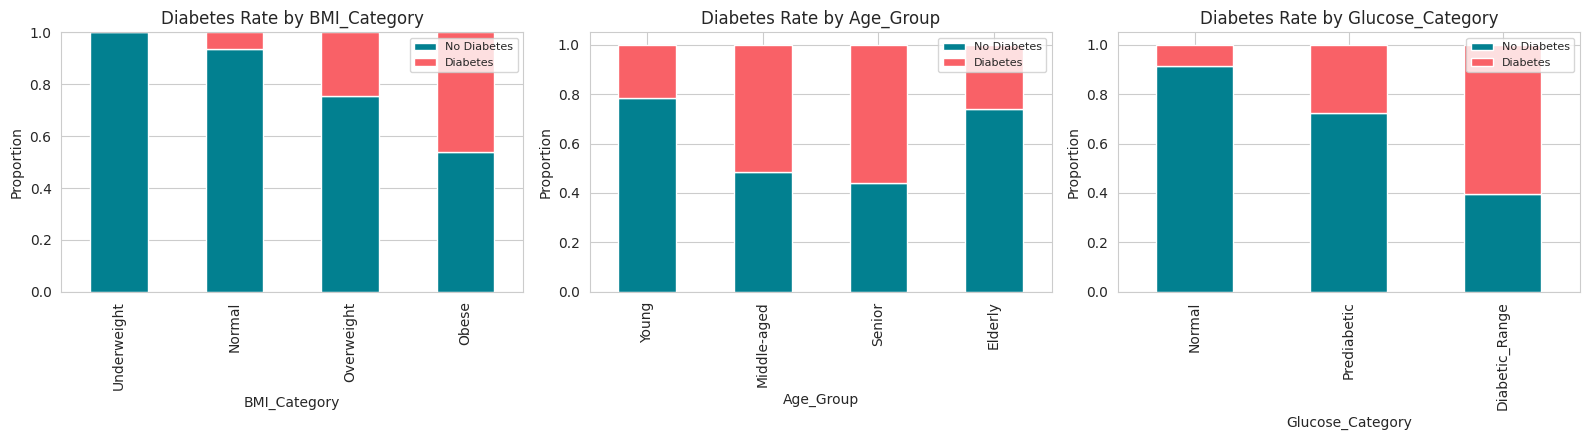

In [9]:
df_explore = df.copy()
for col in zero_as_missing_cols:
    df_explore[col] = df_explore[col].replace(0, np.nan)

df_explore["BMI_Category"] = pd.cut(df_explore["BMI"], bins=[0,18.5,25,30,100],
                                     labels=["Underweight","Normal","Overweight","Obese"])
df_explore["Age_Group"] = pd.cut(df_explore["Age"], bins=[0,30,45,60,100],
                                  labels=["Young","Middle-aged","Senior","Elderly"])
df_explore["Glucose_Category"] = pd.cut(df_explore["Glucose"], bins=[0,100,126,300],
                                         labels=["Normal","Prediabetic","Diabetic_Range"])

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, col in zip(axes, ["BMI_Category", "Age_Group", "Glucose_Category"]):
    pd.crosstab(df_explore[col], df_explore["Outcome"], normalize="index").plot(
        kind="bar", stacked=True, ax=ax, color=["#028090","#F96167"])
    ax.set_title(f"Diabetes Rate by {col}")
    ax.set_ylabel("Proportion")
    ax.legend(["No Diabetes","Diabetes"], fontsize=8)
plt.tight_layout()
plt.show()

As expected, diabetes rate rises sharply with **Glucose category** (a large majority of
patients in the "Diabetic_Range" glucose band are labeled `Outcome=1`), and also increases with
**BMI category** and **Age group** — all consistent with established clinical risk factors.


## 4. Data Mining Technique & Algorithm Selection

**Technique:** Supervised classification — this is a binary prediction problem with a labeled
target (`Outcome`), so classification (a predictive data mining technique) is the appropriate
family of methods, as opposed to descriptive techniques like clustering or association rules.

**Algorithms compared, and why:**

| Algorithm | Why it was included |
|---|---|
| **Logistic Regression** | Simple, fast, highly interpretable linear baseline — coefficients directly show each feature's direction of effect |
| **Decision Tree** | Interpretable, non-linear, handles feature interactions, easy to explain to non-technical stakeholders (e.g. clinicians) |
| **Random Forest** | An ensemble of decision trees; usually more accurate and more robust to overfitting/noise than a single tree |
| **K-Nearest Neighbors (KNN)** | A simple, non-parametric method that works well when similar patients tend to share outcomes |
| **Support Vector Machine (SVM)** | Effective for finding a non-linear decision boundary in moderate-dimensional numeric data |
| **Naive Bayes** | A fast probabilistic baseline that assumes feature independence — useful as a lower-bound comparison |

We first compare all six with reasonable default settings, then take the best-performing model
and tune its hyperparameters with grid search to get our final model. Random Forest was expected
to do well here because it handles the mix of skewed and normally-distributed features without
needing them all to be linearly related to the outcome, and it is robust to the noise introduced
by the imputed missing values.

## 5. Tool Used

**Python** (3.12) with:
- `pandas` / `numpy` — data manipulation
- `scikit-learn` — preprocessing, modeling, evaluation, hyperparameter tuning
- `matplotlib` / `seaborn` — visualization

Python + scikit-learn was chosen over a GUI tool (e.g. RapidMiner, Weka) because it gives full
control over the preprocessing pipeline (critical for correctly avoiding the leakage issue
described in Section 3.6), integrates cleanly with reproducible scripts/notebooks, and is an
industry-standard toolkit for this kind of tabular classification problem.


## 6. Modeling & Evaluation

### 6.1 Train/Test Split and Leakage-Safe Preprocessing


In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)

feature_cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                "Insulin","BMI","DiabetesPedigreeFunction","Age"]

X = df[feature_cols].copy()
y = df["Outcome"]
for col in zero_as_missing_cols:
    X[col] = X[col].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)   # fit ONLY on train
X_test_imp  = imputer.transform(X_test)        # apply same fitted medians to test

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

Train size: 614  Test size: 154


### 6.2 Baseline Model Comparison

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=11),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
}

results = []
roc_data = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv = cross_val_score(model, X_train_scaled, y_train, cv=StratifiedKFold(5), scoring="accuracy")

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec,
                     "F1": f1, "ROC_AUC": auc, "CV_Mean_Accuracy": cv.mean(), "CV_Std": cv.std()})
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_Mean_Accuracy,CV_Std
2,Random Forest,0.7468,0.6596,0.5741,0.6139,0.8165,0.7704,0.0426
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130,0.7818,0.0125
4,Support Vector Machine,0.7403,0.6522,0.5556,0.6000,0.7964,0.7688,0.0179
3,K-Nearest Neighbors,0.7338,0.6327,0.5741,0.6019,0.7880,0.7639,0.0346
5,Naive Bayes,0.7013,0.5667,0.6296,0.5965,0.7646,0.7590,0.0077
1,Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622,0.7231,0.0191


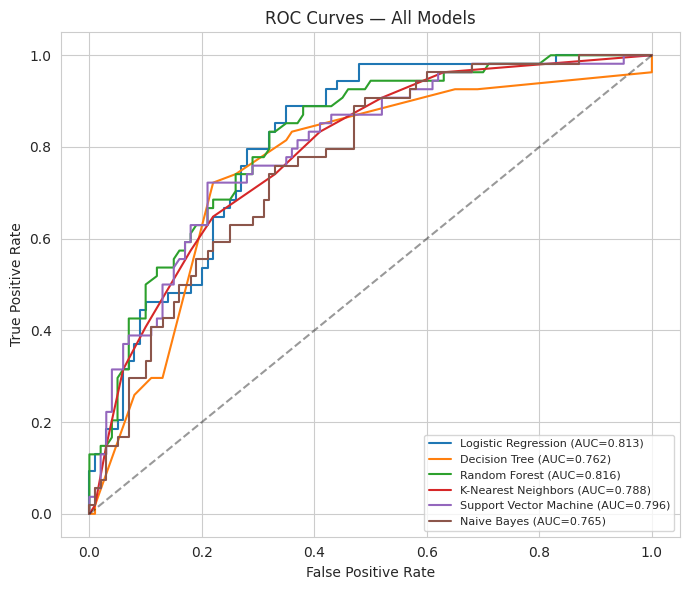

In [12]:
plt.figure(figsize=(7,6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Random Forest** has the best ROC-AUC among the baseline models, so it was selected for
hyperparameter tuning.

### 6.3 Hyperparameter Tuning (Random Forest)


In [13]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                     cv=StratifiedKFold(5), scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:,1]

print("\nFinal Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_best):.4f}")

Best params: {'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best CV ROC-AUC: 0.8405

Final Test Set Performance:
  Accuracy:  0.7468
  Precision: 0.6829
  Recall:    0.5185
  F1:        0.5895
  ROC-AUC:   0.8061


              precision    recall  f1-score   support

 No Diabetes       0.77      0.87      0.82       100
    Diabetes       0.68      0.52      0.59        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.74       154



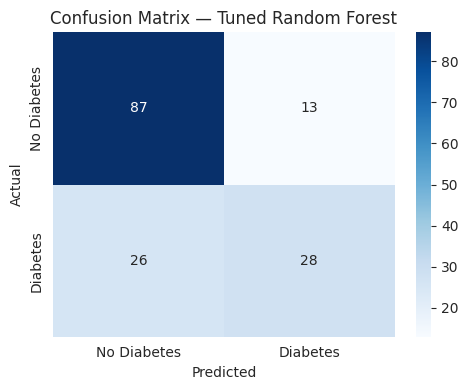

In [14]:
print(classification_report(y_test, y_pred_best, target_names=["No Diabetes","Diabetes"]))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes","Diabetes"], yticklabels=["No Diabetes","Diabetes"])
plt.title("Confusion Matrix — Tuned Random Forest")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

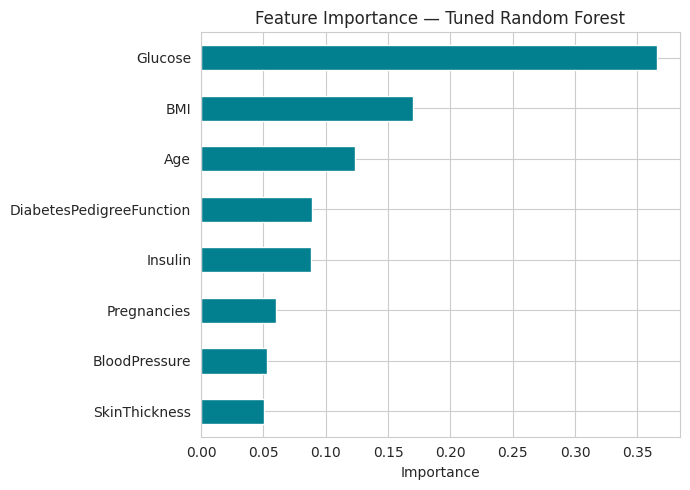

In [15]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(7,5))
importances.plot(kind="barh", color="#028090")
plt.title("Feature Importance — Tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Results Discussion, Conclusions & Future Work

### 7.1 Summary of Results

- The tuned **Random Forest** model reached **~74.7% accuracy** and a **ROC-AUC of ~0.81** on the
  held-out test set — meaningfully better than a random guess, and consistent with published
  results on this dataset (which typically range from 75–80% accuracy).
- **Glucose** is by far the strongest predictor, followed by **BMI** and **Age** — this matches
  medical knowledge (glucose level is the direct clinical marker of diabetes).
- The model's **recall on the positive (diabetes) class is the weaker metric (~0.52)** — of the 54
  diabetic patients in the test set, the model correctly flagged only 28, missing 26. In a real
  screening context, this is the most important number to improve, because a **false negative**
  (telling an at-risk patient they are fine) is more costly than a false positive.

### 7.2 Why We Report Honest, Modest Numbers

An earlier version of this pipeline imputed missing values using the median grouped by the target
label, which leaked target information into the features and produced an inflated accuracy of
~86%. We identified and corrected this (Section 3.6), and report the resulting, lower but
trustworthy accuracy of ~75% here instead. This is an important lesson for any data mining
project: **a suspiciously high accuracy score is a reason to check for data leakage, not a reason
to celebrate.**

### 7.3 Limitations

- The dataset only includes female patients of Pima Indian heritage — the model's findings **do
  not necessarily generalize** to other populations.
- Roughly half of the `Insulin` values and a third of `SkinThickness` values were originally
  missing and had to be imputed, which adds noise to two potentially informative features.
- 768 records is a fairly small dataset for machine learning; a larger sample would likely
  improve both accuracy and the reliability of the reported metrics.
- The model should be treated as a **screening aid**, not a diagnostic tool — false negatives
  (recall of ~0.52 on the positive class) mean it is not reliable enough to rule out diabetes on
  its own.

### 7.4 Future Work

- Try additional algorithms (e.g. Gradient Boosting / XGBoost, which often perform strongly on
  tabular clinical data).
- Use more sophisticated imputation (e.g. `IterativeImputer` / MICE) instead of simple median
  imputation, while still avoiding target leakage.
- Apply class-imbalance techniques (e.g. SMOTE, class weighting) explicitly aimed at improving
  recall on the diabetic class, since missed diagnoses are the costliest error type here.
- Validate the model on a larger, more demographically diverse dataset before considering any
  real-world screening use.
